In [29]:
import pandas as pd
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [30]:
PROCESSED = '../../data/processed'

FEATURES_AVG = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2',
                'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu',
                'is_holiday', 'is_weekend',
                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]
FEATURES_REG = WEATHER_COLS + ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

TARGET = 'load_mw'

torch.manual_seed(1)


In [31]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden=(128, 64, 32), dropout=0.1):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def to_tensor(frame, cols):
    return torch.tensor(frame[cols].values, dtype=torch.float32)

In [32]:
train = pd.read_csv(f'{PROCESSED}/combined_hourly_train.csv', parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(f'{PROCESSED}/combined_hourly_test.csv',  parse_dates=['datetime'], index_col='datetime')

with open(f'{PROCESSED}/combined_hourly_scaler.json') as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

print(f'Train: {len(train):,}  {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test:  {len(test):,}   {test.index[0].date()} to {test.index[-1].date()}')
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')
print(f'{len(FEATURES_AVG)} input features')

X_train = to_tensor(train, FEATURES_AVG)
y_train = to_tensor(train, [TARGET])
X_test  = to_tensor(test,  FEATURES_AVG)
y_test  = to_tensor(test,  [TARGET])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=2048, shuffle=True)
print('X_train shape:', X_train.shape)

Train: 42,076  2019-01-02 to 2023-10-20
Test:  10,519   2023-10-20 to 2024-12-31
load_mw  mean=25225.2 MW  std=4789.3 MW  (train only)
14 input features
X_train shape: torch.Size([42076, 14])


In [33]:
model = MLP(in_features=len(FEATURES_AVG), hidden=(32, 16))

In [34]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 80
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test), y_test).item()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch}  train={train_loss}  test={test_loss}')

Epoch 10  train=0.161293197955404  test=0.13906283676624298
Epoch 20  train=0.12172412588482812  test=0.1184263527393341
Epoch 30  train=0.10519176437741234  test=0.11453929543495178
Epoch 40  train=0.10361678933813459  test=0.11362142860889435
Epoch 50  train=0.10240934718222845  test=0.11361686140298843
Epoch 60  train=0.10173556102173668  test=0.1127396896481514
Epoch 70  train=0.10053074217977978  test=0.1128912940621376
Epoch 80  train=0.1010727257955642  test=0.11281023919582367


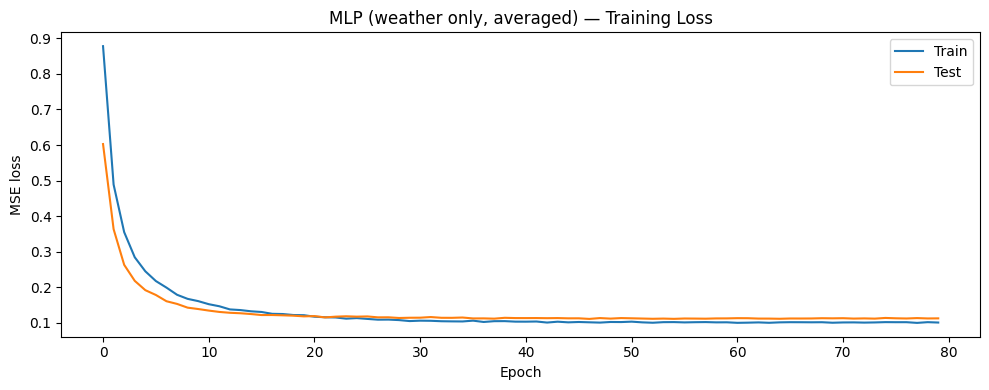

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(test_losses,  label='Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('MLP (weather only, averaged) — Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
model.eval()
with torch.no_grad():
    pred = model(X_test).squeeze().numpy()

y_true = y_test.squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'MLP (weather only, averaged)')
print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'  R2    {r2:.4f}')

MLP (weather only, averaged)
  RMSE  0.3359  (1609 MW)
  MAE   0.2484  (1190 MW)
  R2    0.8804


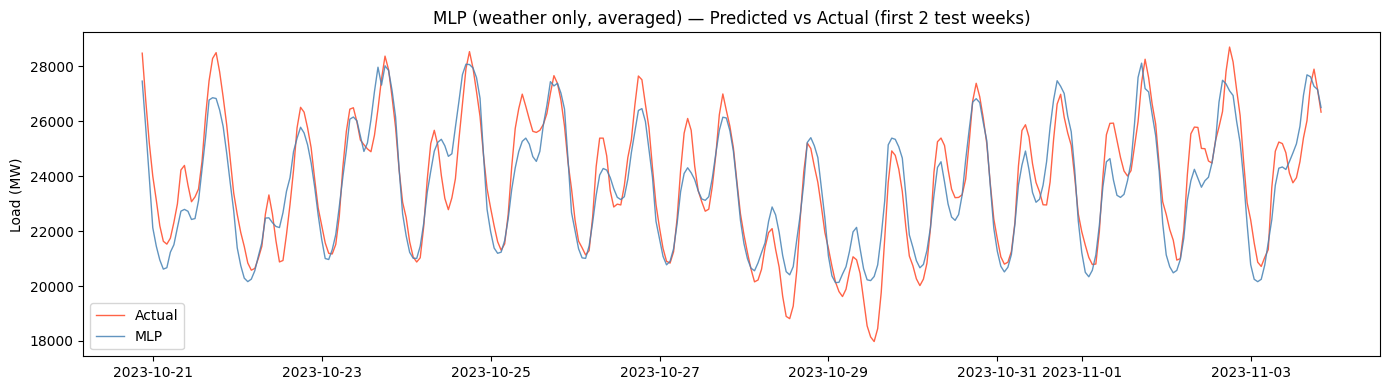

In [37]:
n   = 24 * 14
idx = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual, color='tomato', linewidth=1, label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='MLP')
ax.set_ylabel('Load (MW)')
ax.set_title('MLP (weather only, averaged) — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
train = pd.read_csv(f'{PROCESSED}/combined_hourly_regional_train.csv', parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(f'{PROCESSED}/combined_hourly_regional_test.csv',  parse_dates=['datetime'], index_col='datetime')

with open(f'{PROCESSED}/combined_hourly_regional_scaler.json') as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

X_train = to_tensor(train, FEATURES_REG)
y_train = to_tensor(train, [TARGET])
X_test  = to_tensor(test,  FEATURES_REG)
y_test  = to_tensor(test,  [TARGET])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=2048, shuffle=True)

In [39]:
model = MLP(in_features=len(FEATURES_REG), hidden=(32, 16))

In [40]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 100
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test), y_test).item()

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  train={train_loss:.4f}  test={test_loss:.4f}')

Epoch  10  train=0.1359  test=0.1121
Epoch  20  train=0.1072  test=0.1052
Epoch  30  train=0.0926  test=0.0966
Epoch  40  train=0.0857  test=0.1001
Epoch  50  train=0.0847  test=0.0966
Epoch  60  train=0.0829  test=0.0945
Epoch  70  train=0.0809  test=0.0963
Epoch  80  train=0.0813  test=0.0968
Epoch  90  train=0.0828  test=0.0967
Epoch 100  train=0.0815  test=0.0957


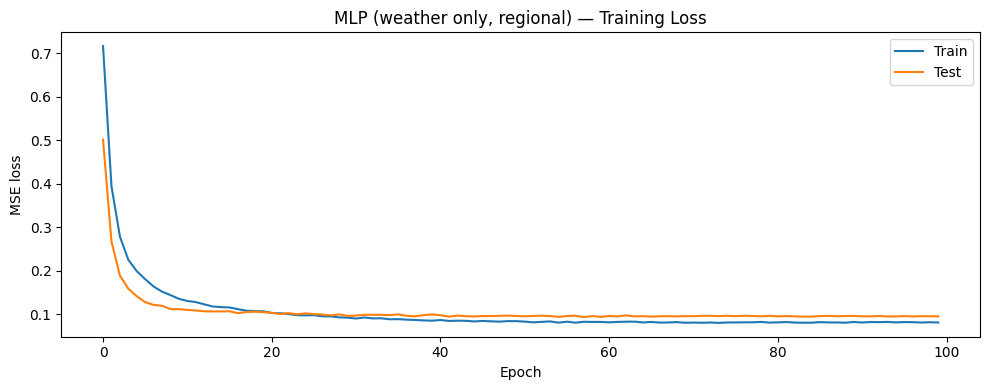

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(test_losses,  label='Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('MLP (weather only, regional) — Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
model.eval()
with torch.no_grad():
    pred = model(X_test).squeeze().numpy()

y_true = y_test.squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'MLP (weather only, regional)')
print(f'RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'R2    {r2:.4f}')

MLP (weather only, regional)
RMSE  0.3093  (1481 MW)
MAE   0.2315  (1109 MW)
R2    0.8986


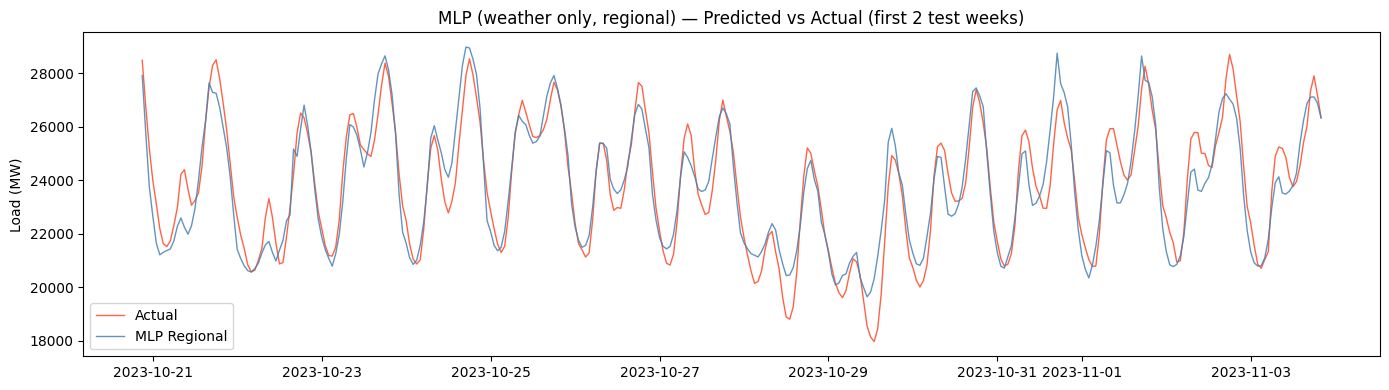

In [43]:
n   = 24 * 14
idx = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual, color='tomato', linewidth=1, label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='MLP Regional')
ax.set_ylabel('Load (MW)')
ax.set_title('MLP (weather only, regional) — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()